### Part 1 — Figure Size & Styling


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Sales_Data_Cleaned")

In [3]:
df

,Order_ID,Date,Product,Category,Quantity,Price,City,OrderYear,OrderMonth,OrderDay
0,1001,2026-01-11,Mobile,Electronics,3.0,42750.0,Lahore,2026,1,11
1,1002,2026-01-31,Headphones,Electronics,5.0,6175.0,Peshawar,2026,1,31
2,1003,2026-01-13,Printer,Office,1.0,26600.0,Lahore,2026,1,13
3,1004,2026-05-14,Keyboard,Accessories,5.0,4275.0,Peshawar,2026,5,14
4,1005,2026-06-20,Keyboard,Accessories,5.0,4500.0,Lahore,2026,6,20
5,1006,2026-06-04,Notebook,Stationery,3.0,475.0,Lahore,2026,6,4
6,1007,2026-04-02,Printer,Office,3.0,26600.0,Lahore,2026,4,2
7,1008,2026-01-31,Monitor,Electronics,3.0,32000.0,Islamabad,2026,1,31
8,1009,2026-04-03,Monitor,Electronics,5.0,32000.0,Islamabad,2026,4,3
9,1010,2026-05-22,Notebook,Stationery,1.0,500.0,Islamabad,2026,5,22


In [4]:
df["Date"]=pd.to_datetime(df["Date"])

In [5]:
df["MonthName"]=df["Date"].dt.month_name()

In [6]:
df["Revenue"]=df["Quantity"]*df["Price"]

In [7]:
df

,Order_ID,Date,Product,Category,Quantity,Price,City,OrderYear,OrderMonth,OrderDay,MonthName,Revenue
0,1001,2026-01-11,Mobile,Electronics,3.0,42750.0,Lahore,2026,1,11,January,128250.0
1,1002,2026-01-31,Headphones,Electronics,5.0,6175.0,Peshawar,2026,1,31,January,30875.0
2,1003,2026-01-13,Printer,Office,1.0,26600.0,Lahore,2026,1,13,January,26600.0
3,1004,2026-05-14,Keyboard,Accessories,5.0,4275.0,Peshawar,2026,5,14,May,21375.0
4,1005,2026-06-20,Keyboard,Accessories,5.0,4500.0,Lahore,2026,6,20,June,22500.0
5,1006,2026-06-04,Notebook,Stationery,3.0,475.0,Lahore,2026,6,4,June,1425.0
6,1007,2026-04-02,Printer,Office,3.0,26600.0,Lahore,2026,4,2,April,79800.0
7,1008,2026-01-31,Monitor,Electronics,3.0,32000.0,Islamabad,2026,1,31,January,96000.0
8,1009,2026-04-03,Monitor,Electronics,5.0,32000.0,Islamabad,2026,4,3,April,160000.0
9,1010,2026-05-22,Notebook,Stationery,1.0,500.0,Islamabad,2026,5,22,May,500.0


In [8]:
df.to_csv("Sales_Data_Cleaned.csv",index=False)

Q1

Create a Revenue by Product bar chart with:

figsize=(10,6)

Proper title

X-axis label,
Y-axis label

Rotated product names if needed

Grid on the Y-axis

In [9]:
product_revenue=df.groupby("Product")["Revenue"].sum()

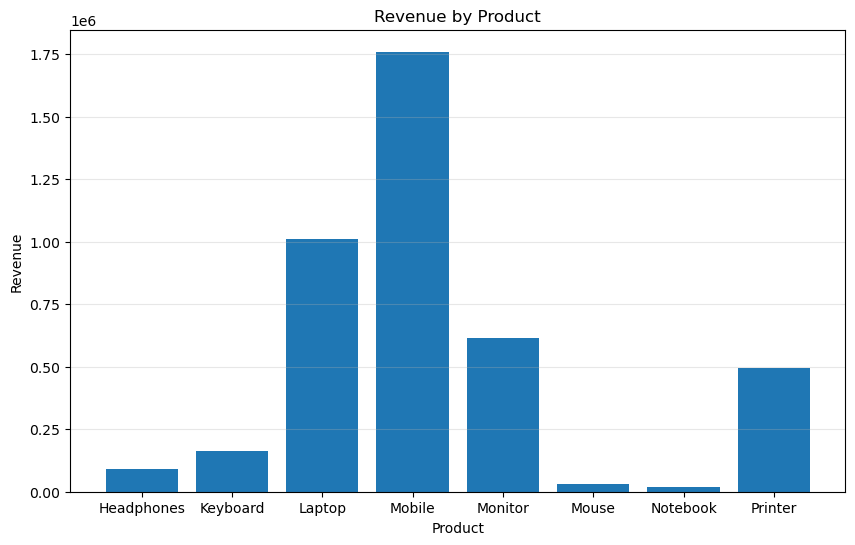

In [10]:
plt.figure(figsize=(10,6))

plt.bar(product_revenue.index, product_revenue.values)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Part 2 — Sort Before Plotting

Q2

Create a City Revenue bar chart where cities are arranged from:

Highest → Lowest revenue

In [11]:
city_revenue=df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

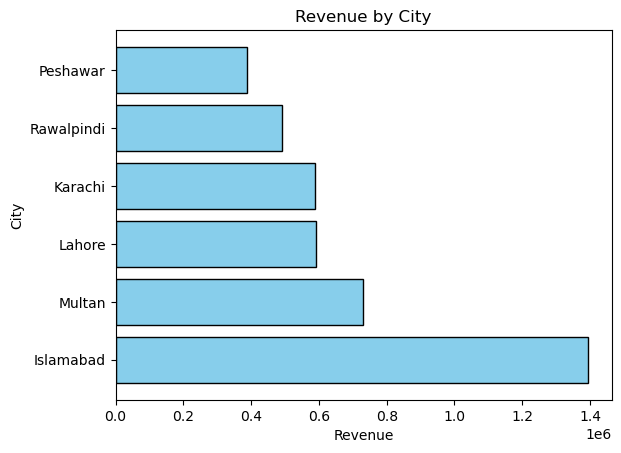

In [12]:
plt.barh(city_revenue.index,city_revenue.values,color='skyblue', edgecolor='black')

plt.title("Revenue by City")
plt.xlabel("Revenue")
plt.ylabel("City")


plt.show()

Sorting helps us to analyze how a variable is increasing/decreasing with change in another varaible.

### Part 3 — Add Values to Bars


Q3 ⭐

Create a Product Revenue bar chart and display the revenue value above each bar.

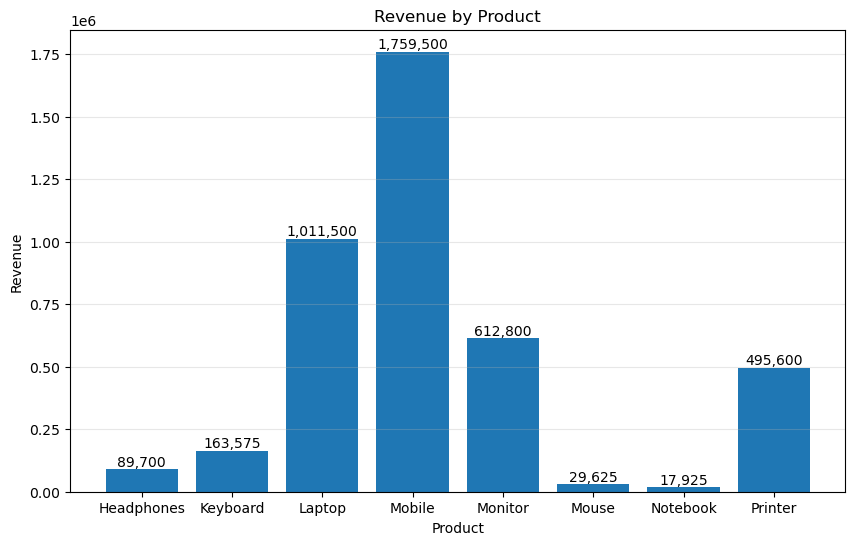

In [13]:
plt.figure(figsize=(10,6))

plt.bar(product_revenue.index, product_revenue.values)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(product_revenue.values):
    plt.text(i, value, f"{value:,.0f}",
             ha="center", va="bottom")

plt.show()

### Part 4 — Correct Month Ordering

Q4

Create a proper monthly revenue chart with months in chronological order:

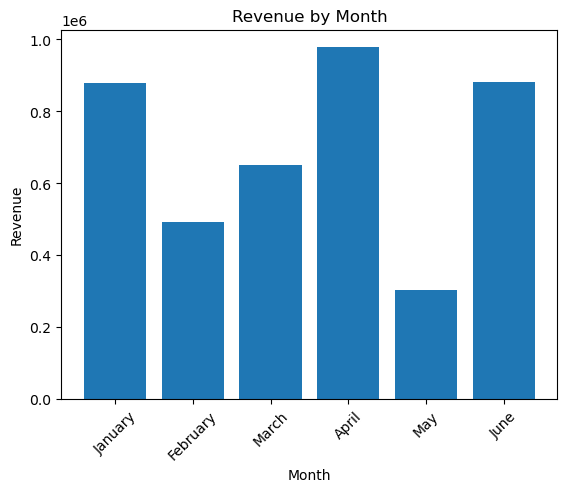

In [14]:
month_order = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

df["MonthName"]=pd.Categorical(
    df["MonthName"],
    categories=month_order,
    ordered=True
)

monthly_revenue=df.groupby("MonthName",observed=True)["Revenue"].sum()
monthly_quantity=df.groupby("MonthName",observed=True)["Quantity"].sum()

plt.bar(monthly_revenue.index, monthly_revenue.values)

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

To analyze a trend of revenue in different months ,choronical order of month is used. Actual Month names are not alphatically ordered.

### Part 5 — Subplots

Create two charts in one figure:

Chart 1

Monthly Quantity Sold

Chart 2

Monthly Revenue

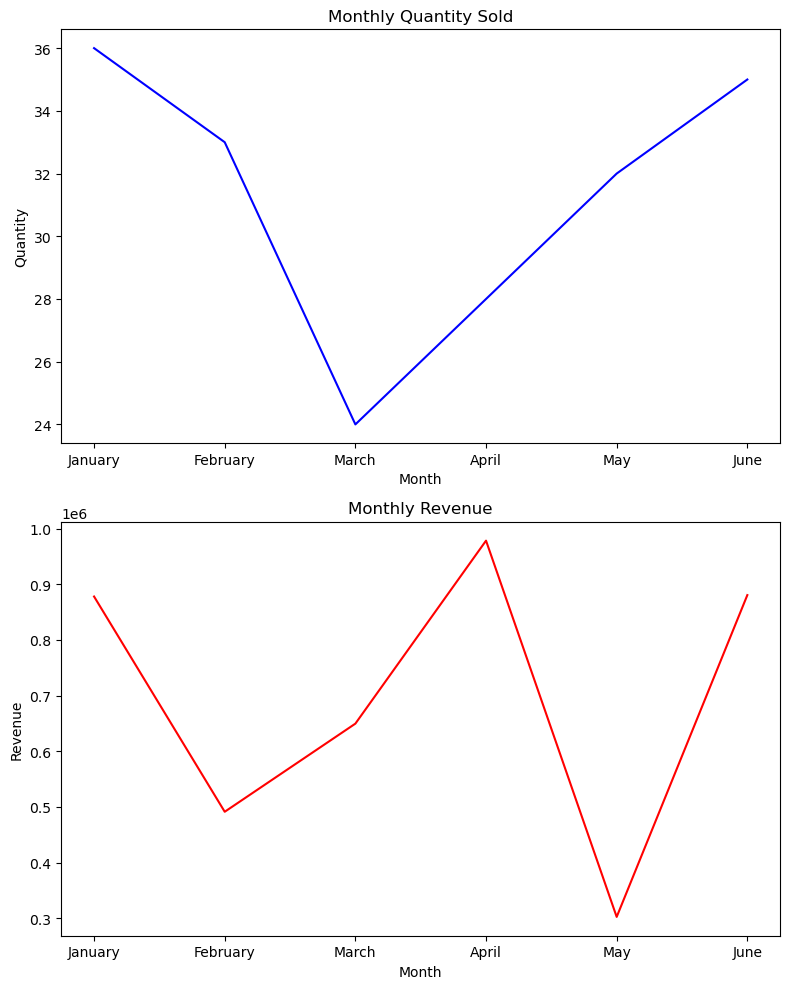

In [15]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(8, 10))

ax1.plot(monthly_quantity.index,monthly_quantity.values,color="blue")
ax1.set_title("Monthly Quantity Sold")
ax1.set_xlabel("Month")
ax1.set_ylabel("Quantity")

ax2.plot(monthly_revenue.index,monthly_revenue.values,color="red")
ax2.set_title("Monthly Revenue")
ax2.set_xlabel("Month")
ax2.set_ylabel("Revenue")

plt.tight_layout()
plt.show()


### Part 6 — Two Y-Axes

Q6:

Monthly Quantity vs Monthly Revenue

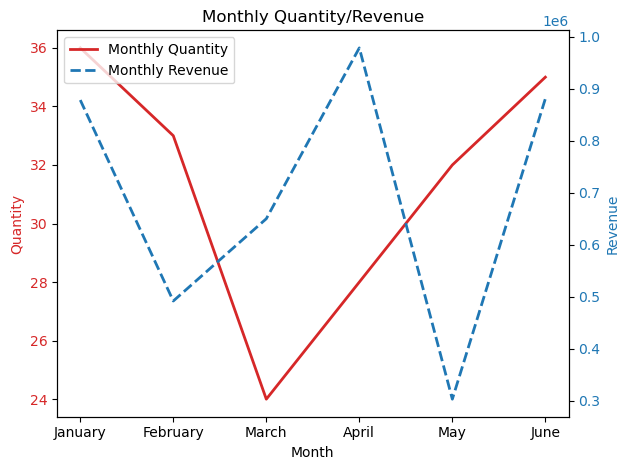

In [16]:
fig, ax1 = plt.subplots()
color_left = 'tab:red'
ax1.set_xlabel("Month")
ax1.set_ylabel('Quantity', color=color_left)
ax1.plot(monthly_quantity.index, monthly_quantity.values, color=color_left, linewidth=2, label='Monthly Quantity')
ax1.tick_params(axis='y', labelcolor=color_left)

ax2 = ax1.twinx()  

color_right = 'tab:blue'
ax2.set_ylabel('Revenue', color=color_right)
ax2.plot(monthly_revenue.index, monthly_revenue.values, color=color_right, linewidth=2, linestyle='--', label='Monthly Revenue')
ax2.tick_params(axis='y', labelcolor=color_right)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('Monthly Quantity/Revenue')
fig.tight_layout()
plt.show()


Two Y-axis helps to analyze the trend over a period of time and to compare the two variables.

### Part 7 — Annotations

Create a monthly revenue line chart.

Identify the month with the highest revenue and annotate it.

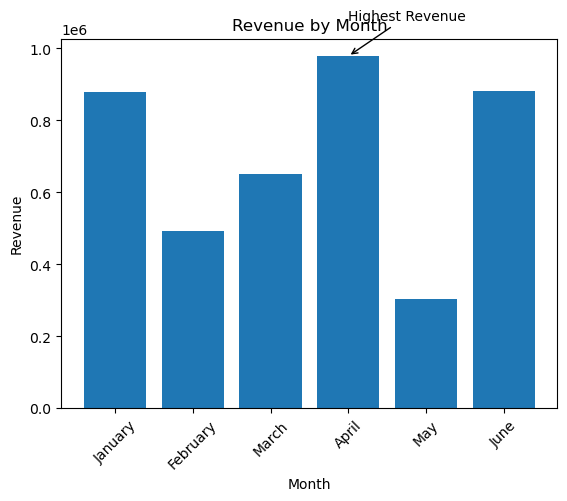

In [17]:
plt.bar(
    range(len(monthly_revenue)),
    monthly_revenue.values
)

plt.xticks(
    range(len(monthly_revenue)),
    monthly_revenue.index,
    rotation=45
)

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")

max_month = monthly_revenue.idxmax()
max_revenue = monthly_revenue.max()
max_position = monthly_revenue.index.get_loc(max_month)

plt.annotate(
    "Highest Revenue",
    xy=(max_position, max_revenue),
    xytext=(max_position, max_revenue + 100000),
    arrowprops=dict(arrowstyle="->")
)

plt.show()

### Part 8 — Choose the Best Visualization

Q8

Which product generates the most revenue?
Bar Chart is useful to compare two or more categories.

Q9

How does revenue change over the year?

Line chart is useful to see variable trend over a period of time.

Q10

What is the distribution of order revenue?

Histogram is useful to see the distribution of a variable whether it is right-ward/leftward skewed

Q11

Is there a relationship between Quantity and Revenue?

Scattered plot is useful to see a linear trend between two variables.

Q12 ⭐

Compare Revenue and Quantity across different cities.

Explain why you selected your chart.

Multiple bar charts is useful to caompare different categories.

### Part 9 — Mini Business Dashboard

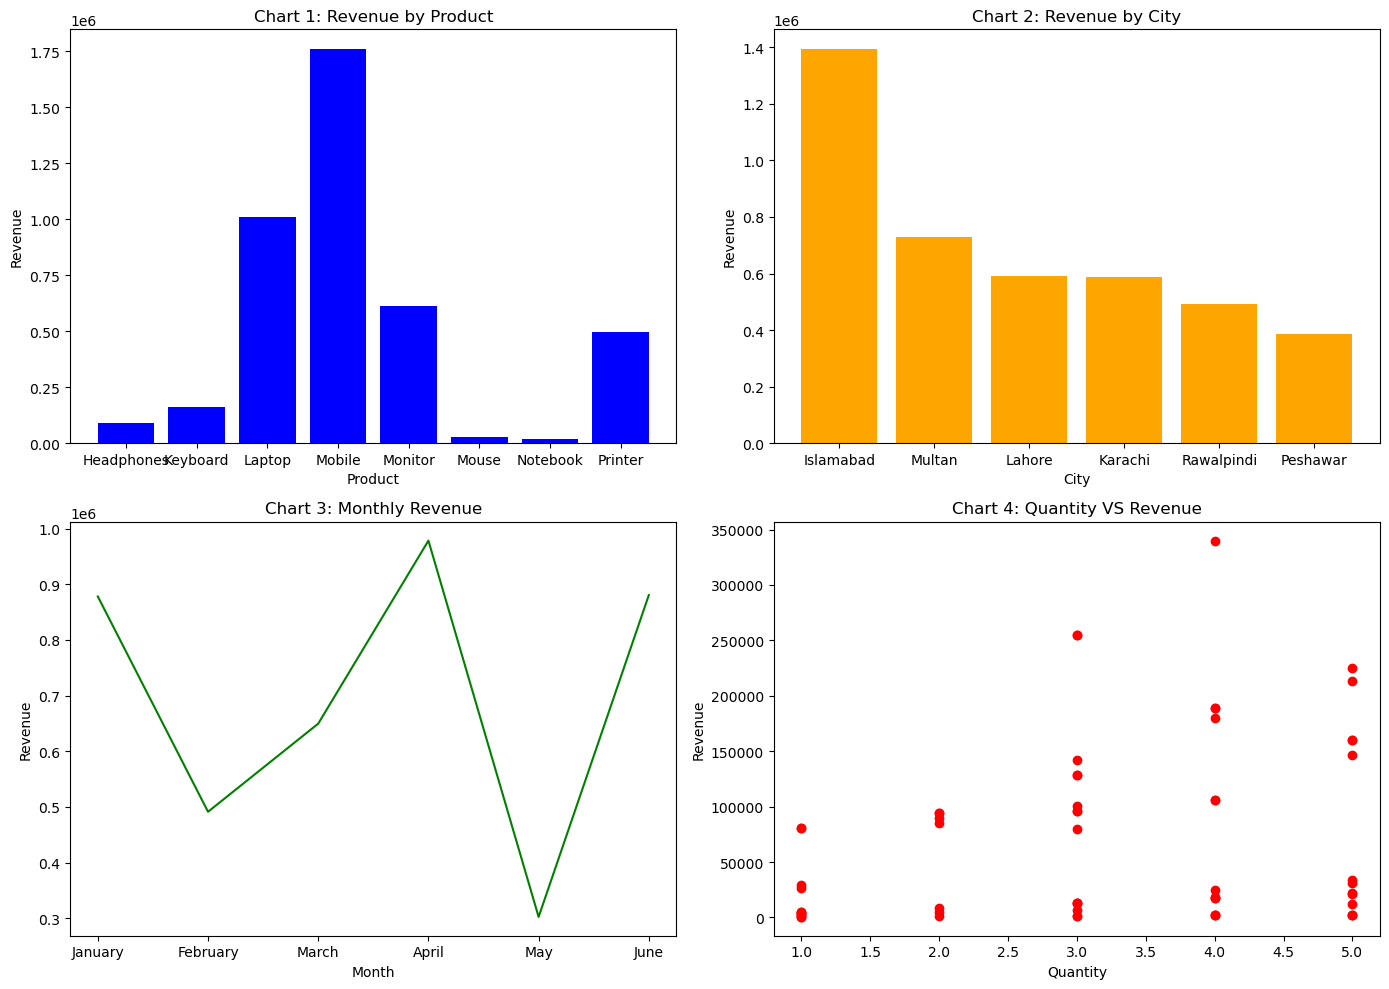

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(product_revenue.index, product_revenue.values, color='blue')
axes[0, 0].set_title('Chart 1: Revenue by Product')
axes[0,0].set_xlabel("Product")
axes[0,0].set_ylabel("Revenue")

axes[0, 1].bar(city_revenue.index, city_revenue.values, color='orange')
axes[0, 1].set_title('Chart 2: Revenue by City')
axes[0,1].set_xlabel("City")
axes[0,1].set_ylabel("Revenue")

axes[1, 0].plot(monthly_revenue.index, monthly_revenue.values, color='green')
axes[1, 0].set_title('Chart 3: Monthly Revenue')
axes[1,0].set_xlabel("Month")
axes[1,0].set_ylabel("Revenue")

axes[1, 1].scatter(df["Quantity"],df["Revenue"],color='red')
axes[1, 1].set_title('Chart 4: Quantity VS Revenue')
axes[1,1].set_xlabel("Quantity")
axes[1,1].set_ylabel("Revenue")

plt.tight_layout()

plt.show()


Key Insights:

1. Mobile,Laptops and monitor generated higher revenue.It implies that company's performance highly depend on the sales of eletronic products.

2. Islamabad is found to be the strongest market among other cities.

3. Monthly revenue did not show any specific trend over a period of time.It reached the max point in the April.

4. There is no evidence of any linear relationship between the Quantity and revenue.As revenue depends on both the price and the quantity of a product.